# Exploratory Data Analysis (EDA)

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 1 Dataset overview & Structure

In [88]:
reviews = pd.read_csv('C:\\Users\\saite\\OneDrive - University of Central Missouri\\Documents\\MS in CS\\Data Analyst\\Projects\\Employee Rentention Analysis\\Datasets\\Glassdoor Reviews Cleaned and Processed.csv')

In [89]:
reviews.head()

,Employeer ID,Employeer Name,Employement Status,job title,length of employement,isCurrent Job,ratingCarrerOpportunities,ratingBusinessoutlook,ratingCEO,ratingCompensationand Benefits,...,rating worklifebalance,countHelpful,countNothelpful,summary,Cons,pros,reviewdate,reviewtime,city,state
0,5224839,JPMorganChase,REGULAR,Private Client Banker,9,True,4,POSITIVE,APPROVE,3,...,5,0,0,"Great Company, Location &amp; Team Dependent",Dependent on team and location. Lots of widget...,Great place to learn the industry. If you're i...,2025-05-18,23:05:00,Los Angeles,CA
1,5224839,JPMorganChase,REGULAR,Senior Associate,6,True,5,POSITIVE,APPROVE,5,...,5,0,0,Good place to work,Pay is on lower end,"Friendly people, collaborative, good culture",2025-05-31,09:15:00,New York,NY
2,5224839,JPMorganChase,REGULAR,Personal Banker,4,True,2,NaN,APPROVE,4,...,3,0,0,"Great Brand and Resources, But Support Varies ...",•\tThe employee experience depends heavily on ...,•\tThe company offers a well-known name and so...,2025-05-23,21:00:00,Chicago,IL
3,5224839,JPMorganChase,REGULAR,Software Engineer III,2,True,2,NEGATIVE,DISAPPROVE,4,...,4,0,0,Terrible developer experience in a low trust e...,Developer experience at this company is catast...,Interesting problems to work on,2025-05-13,08:11:00,Seattle,WA
4,5224839,JPMorganChase,REGULAR,Process Manager,20,True,3,NEGATIVE,NO_OPINION,2,...,2,0,0,Great company name but doesn't live up to its ...,Top talent continues to be overlooked. Have wa...,Peers are always great to work with. So much t...,2025-04-21,11:25:00,Columbus,OH


In [90]:
reviews.shape

(6977, 24)

In [91]:
reviews.isnull().sum()

Employeer ID                         0
Employeer Name                       0
Employement Status                   0
job title                            0
length of employement                0
isCurrent Job                        0
ratingCarrerOpportunities            0
ratingBusinessoutlook             2857
ratingCEO                         2890
ratingCompensationand Benefits       0
ratingCulutreand Values              0
ratingDiversity and Inclusion        0
rating Overall                       0
ratingSeniorleadership               0
rating worklifebalance               0
countHelpful                         0
countNothelpful                      0
summary                              0
Cons                                 0
pros                                 0
reviewdate                           0
reviewtime                           0
city                                 0
state                                0
dtype: int64

In [92]:
# There are some null values in state column we will remove those values
reviews.dropna(subset=['state'], inplace=True)

#### Checking duplicated rows in the dataset

In [93]:
reviews.duplicated().sum()

np.int64(6)

In [94]:
reviews.drop_duplicates(inplace=True)

In [95]:
reviews.shape

(6971, 24)

In [96]:
reviews.dtypes

Employeer ID                       int64
Employeer Name                    object
Employement Status                object
job title                         object
length of employement              int64
isCurrent Job                       bool
ratingCarrerOpportunities          int64
ratingBusinessoutlook             object
ratingCEO                         object
ratingCompensationand Benefits     int64
ratingCulutreand Values            int64
ratingDiversity and Inclusion      int64
rating Overall                     int64
ratingSeniorleadership             int64
rating worklifebalance             int64
countHelpful                       int64
countNothelpful                    int64
summary                           object
Cons                              object
pros                              object
reviewdate                        object
reviewtime                        object
city                              object
state                             object
dtype: object

In [97]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6971 entries, 0 to 6976
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Employeer ID                    6971 non-null   int64 
 1   Employeer Name                  6971 non-null   object
 2   Employement Status              6971 non-null   object
 3   job title                       6971 non-null   object
 4   length of employement           6971 non-null   int64 
 5   isCurrent Job                   6971 non-null   bool  
 6   ratingCarrerOpportunities       6971 non-null   int64 
 7   ratingBusinessoutlook           4116 non-null   object
 8   ratingCEO                       4083 non-null   object
 9   ratingCompensationand Benefits  6971 non-null   int64 
 10  ratingCulutreand Values         6971 non-null   int64 
 11  ratingDiversity and Inclusion   6971 non-null   int64 
 12  rating Overall                  6971 non-null   int64

In [98]:
reviews.describe()

,Employeer ID,length of employement,ratingCarrerOpportunities,ratingCompensationand Benefits,ratingCulutreand Values,ratingDiversity and Inclusion,rating Overall,ratingSeniorleadership,rating worklifebalance,countHelpful,countNothelpful
count,6.971000e+03,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000,6971.000000
mean,5.684049e+05,4.167264,2.642232,2.833166,2.607947,2.825993,3.668053,2.343710,2.612107,1.046048,0.001721
std,1.899686e+06,5.554284,1.894556,1.909689,1.949856,2.036747,1.208404,1.862585,1.937811,13.808707,0.077607
min,1.200000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4.150000e+02,0.000000,1.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
50%,1.302000e+03,2.000000,3.000000,3.000000,3.000000,3.000000,4.000000,2.000000,3.000000,0.000000,0.000000
75%,8.937000e+03,6.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000,0.000000,0.000000
max,1.027271e+07,20.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,658.000000,4.000000


## 2 Company level summary

### Number of reviews per employeer

In [99]:
reviews.groupby('Employeer Name')['Employeer ID'].agg('count').sort_values(ascending=False)

Employeer Name
NVIDIA               98
Target               96
McDonald's           94
Adobe                93
Delta Air Lines      93
                     ..
Duke Energy          35
Metlife              35
U.S. Bank            34
Booking Holdings      8
Applied Materials     6
Name: Employeer ID, Length: 92, dtype: int64

In [100]:
reviews.groupby('Employeer Name')['Employeer ID'].agg('count').sort_values(ascending=True)

Employeer Name
Applied Materials     6
Booking Holdings      8
U.S. Bank            34
Duke Energy          35
Metlife              35
                     ..
Delta Air Lines      93
Texas Instruments    93
McDonald's           94
Target               96
NVIDIA               98
Name: Employeer ID, Length: 92, dtype: int64

#### Where the highest no of reviews for NIVIDIA and lowest no of reviews for Applied Materials 

### Average rating for a company

In [101]:
average_ratings = reviews.groupby('Employeer Name')['rating Overall'].mean().sort_values(ascending=False)
average_ratings

Employeer Name
NVIDIA                                     4.561224
ConocoPhillips                             4.296296
General Dynamics Information Technology    4.200000
Merck                                      4.176471
KKR                                        4.150685
                                             ...   
U.S. Bank                                  2.941176
BNY                                        2.892857
American Electric Power                    2.888889
Fiserv                                     2.474359
Union Pacific                              2.436782
Name: rating Overall, Length: 92, dtype: float64

### The top 5 companies with good overall rating are NIVIDIA, ConocoPhillips, General Dynamics Information Technology, Merck, KKR (Based on the dataset, which can be varies with new dataset)

# Top 5 Employers by Average Rating

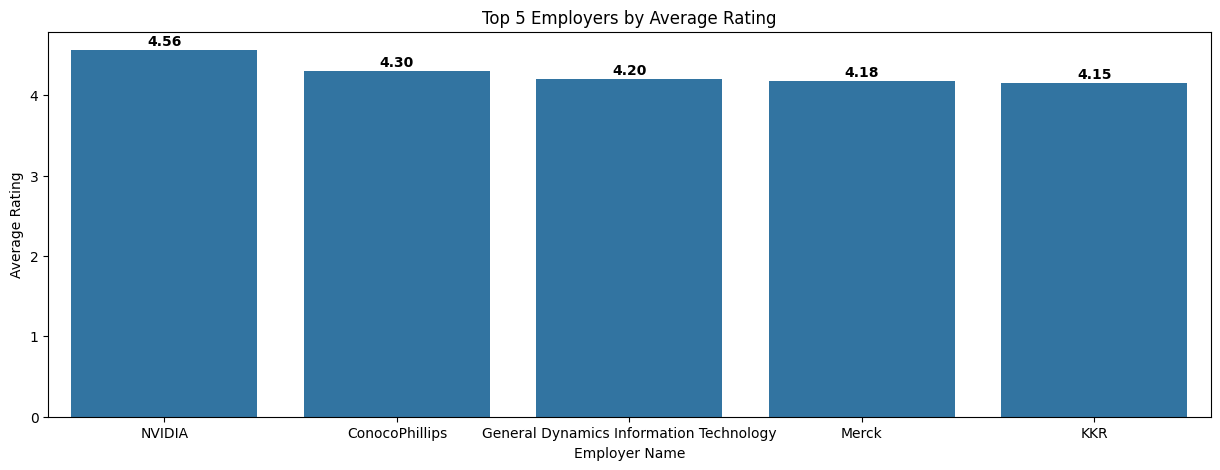

In [102]:
plt.figure(figsize=(15,5))
ax = sns.barplot(x = average_ratings.head(5).index, y = average_ratings.head(5).values, )
plt.xlabel('Employer Name')
plt.ylabel('Average Rating')
plt.title('Top 5 Employers by Average Rating')
for i, v in enumerate(average_ratings.head(5).values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Top 5 Employers by Average Rating.png', dpi=300, bbox_inches='tight')
plt.show()

# Average rating for worklife balance

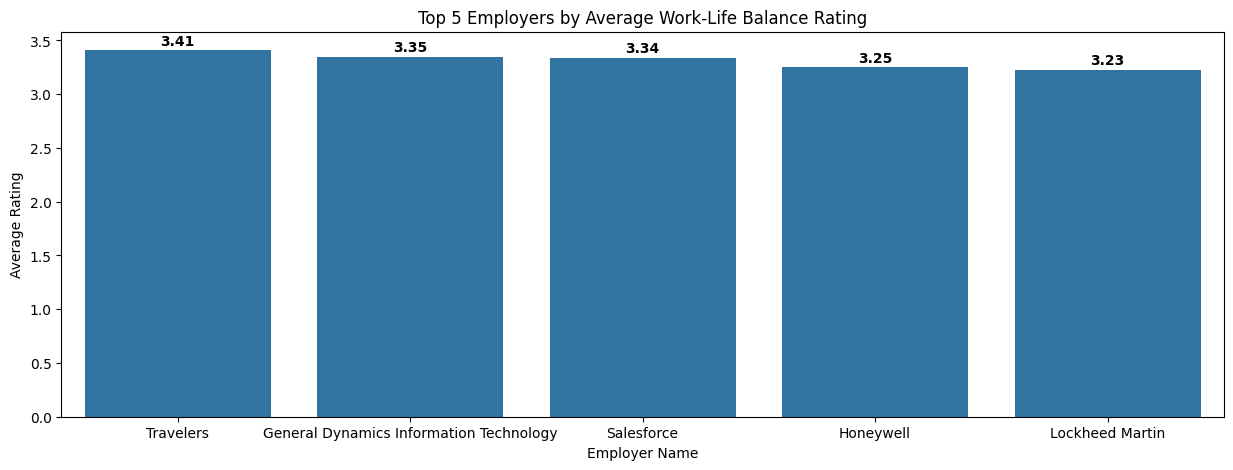

In [103]:
worklife_balance_ratings = reviews.groupby('Employeer Name')['rating worklifebalance'].mean().sort_values(ascending=False)
plt.figure(figsize=(15,5))
ax = sns.barplot(x = worklife_balance_ratings.head(5).index, y = worklife_balance_ratings.head(5).values, )
plt.xlabel('Employer Name')
plt.ylabel('Average Rating')
plt.title('Top 5 Employers by Average Work-Life Balance Rating')
for i, v in enumerate(worklife_balance_ratings.head(5).values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Top 5 Employers by Average Work-Life Balance Rating.png', dpi=300, bbox_inches='tight')
plt.show()

# Average rating of Senior leadership of each employeer

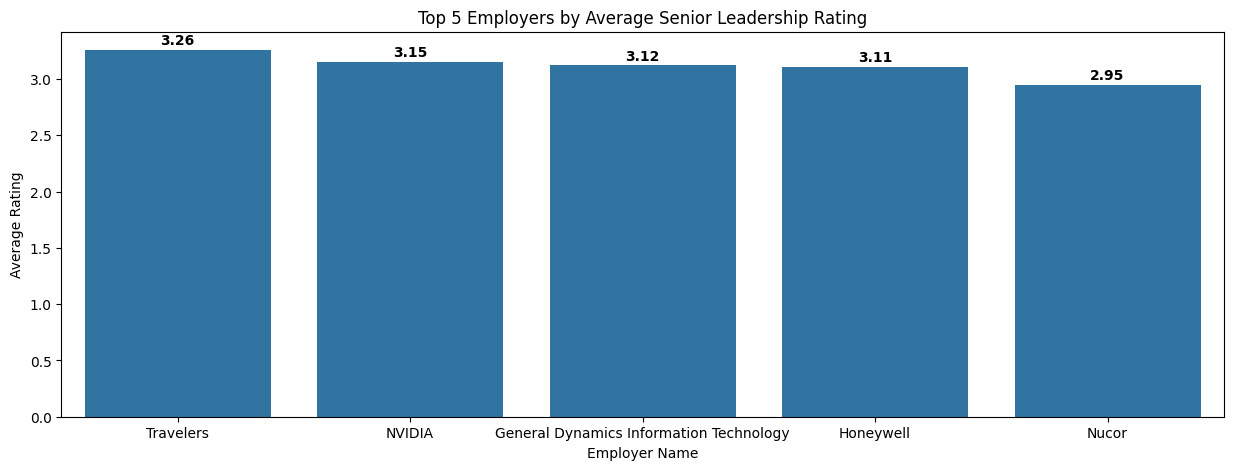

In [104]:
average_seniorleadership = reviews.groupby('Employeer Name')['ratingSeniorleadership'].mean().sort_values(ascending=False)
plt.figure(figsize=(15,5))
ax = sns.barplot(x = average_seniorleadership.head(5).index, y = average_seniorleadership.head(5).values, )
plt.xlabel('Employer Name')
plt.ylabel('Average Rating')
plt.title('Top 5 Employers by Average Senior Leadership Rating')
for i, v in enumerate(average_seniorleadership.head(5).values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Top 5 Employers by Average Senior Leadership Rating.png', dpi=300, bbox_inches='tight')
plt.show()

# Average rating of Carrer Opportunities

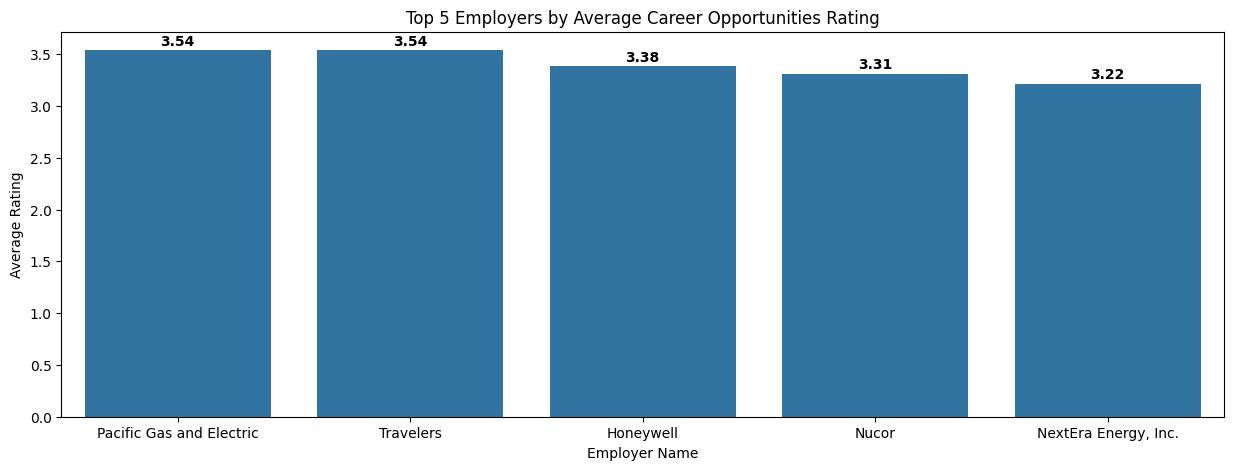

In [105]:
average_career_opportunities = reviews.groupby('Employeer Name')['ratingCarrerOpportunities'].mean().sort_values(ascending=False)
plt.figure(figsize=(15,5))
ax = sns.barplot(x = average_career_opportunities.head(5).index, y = average_career_opportunities.head(5).values, )
plt.xlabel('Employer Name')
plt.ylabel('Average Rating')
plt.title('Top 5 Employers by Average Career Opportunities Rating')
for i, v in enumerate(average_career_opportunities.head(5).values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Top 5 Employers by Average Career Opportunities Rating.png', dpi=300, bbox_inches='tight')
plt.show()  

# Average rating of Compensationand Benefits

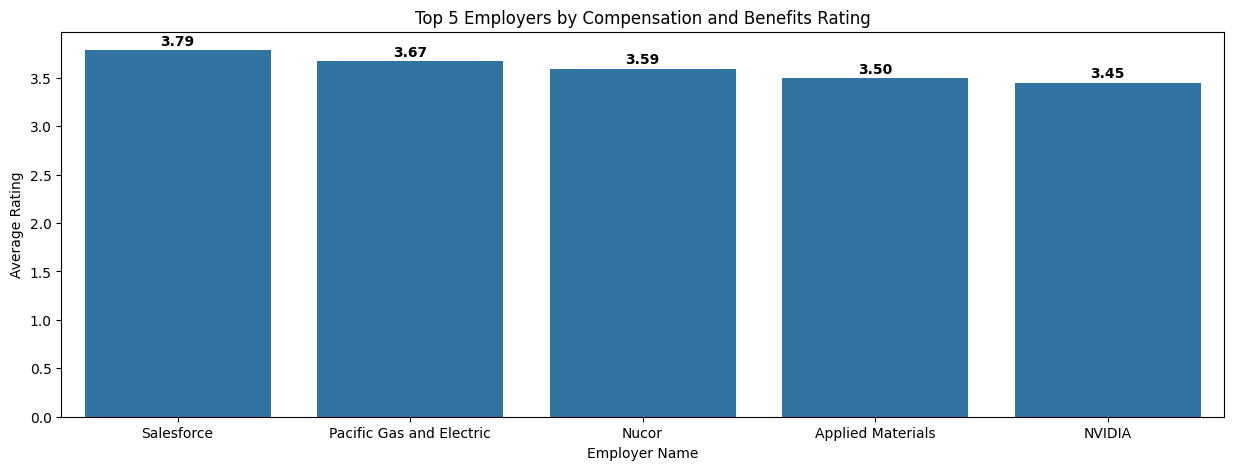

In [106]:
average_compensation_benefits = reviews.groupby('Employeer Name')['ratingCompensationand Benefits'].mean().sort_values(ascending=False)
plt.figure(figsize=(15,5))
ax = sns.barplot(x = average_compensation_benefits.head(5).index, y = average_compensation_benefits.head(5).values, )
plt.xlabel('Employer Name')
plt.ylabel('Average Rating')
plt.title('Top 5 Employers by Compensation and Benefits Rating')
for i, v in enumerate(average_compensation_benefits.head(5).values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Top 5 Employers by Compensation and Benefits Rating.png', dpi=300, bbox_inches='tight')
plt.show()

# Average rating of Culutre and Values

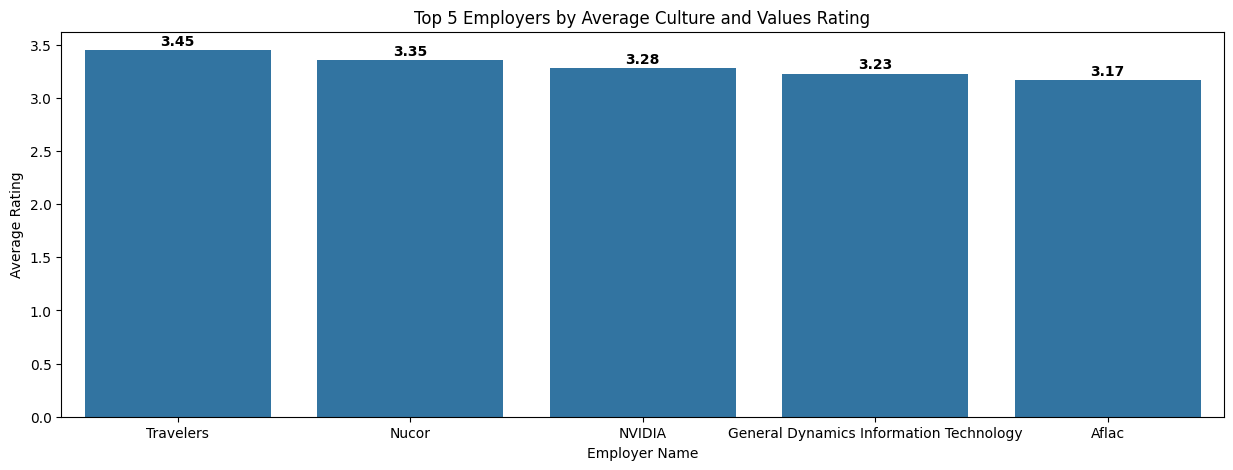

In [107]:
average_culture_values = reviews.groupby('Employeer Name')['ratingCulutreand Values'].mean().sort_values(ascending=False)
plt.figure(figsize=(15,5))
ax = sns.barplot(x = average_culture_values.head(5).index, y = average_culture_values.head(5).values, )
plt.xlabel('Employer Name')
plt.ylabel('Average Rating')
plt.title('Top 5 Employers by Average Culture and Values Rating')
for i, v in enumerate(average_culture_values.head(5).values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Top 5 Employers by Average Culture and Values Rating.png', dpi=300, bbox_inches='tight')
plt.show()

# Average rating of Diversity and Inclusion

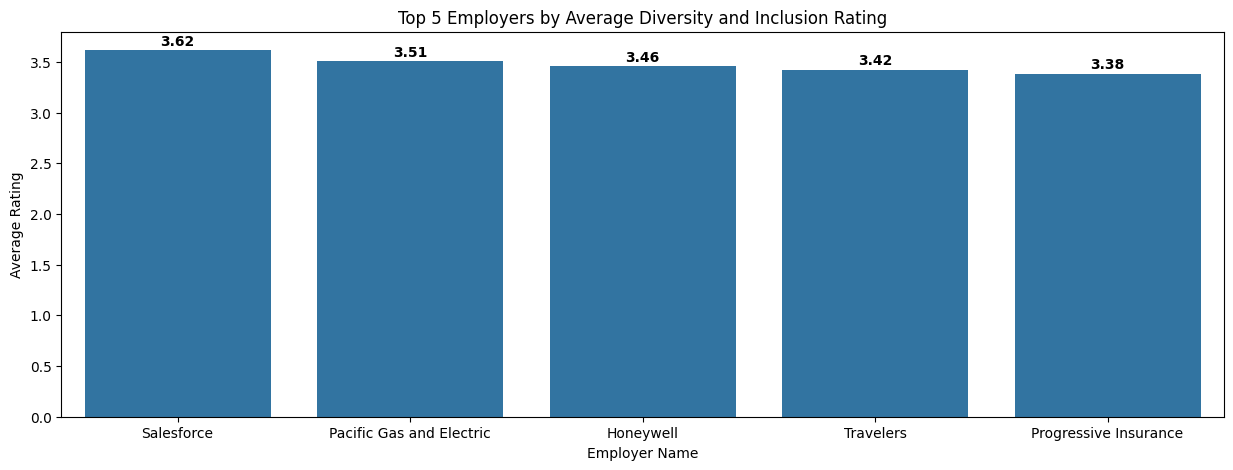

In [108]:
average_diversity_inclusion = reviews.groupby('Employeer Name')['ratingDiversity and Inclusion'].mean().sort_values(ascending=False)
plt.figure(figsize=(15,5))
ax = sns.barplot(x = average_diversity_inclusion.head(5).index, y = average_diversity_inclusion.head(5).values, )
plt.xlabel('Employer Name')
plt.ylabel('Average Rating')
plt.title('Top 5 Employers by Average Diversity and Inclusion Rating')
for i, v in enumerate(average_diversity_inclusion.head(5).values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Top 5 Employers by Average Diversity and Inclusion Rating.png', dpi=300, bbox_inches='tight')
plt.show()

### Summary of Company level analysis

Travelers, NVIDIA, and Pacific Gas and Electric consistently appear among the top-rated employers across multiple metrics including career opportunities, culture, and leadership.

Salesforce leads in both diversity and compensation, indicating strong employee-centric policies, while NVIDIA stands out with the highest overall rating (4.56).

General Dynamics Information Technology shows balanced strength across work-life balance, leadership, and culture, making it one of the most well-rounded employers.

# 3 Role based Analysis

### Number of roles present in dataset

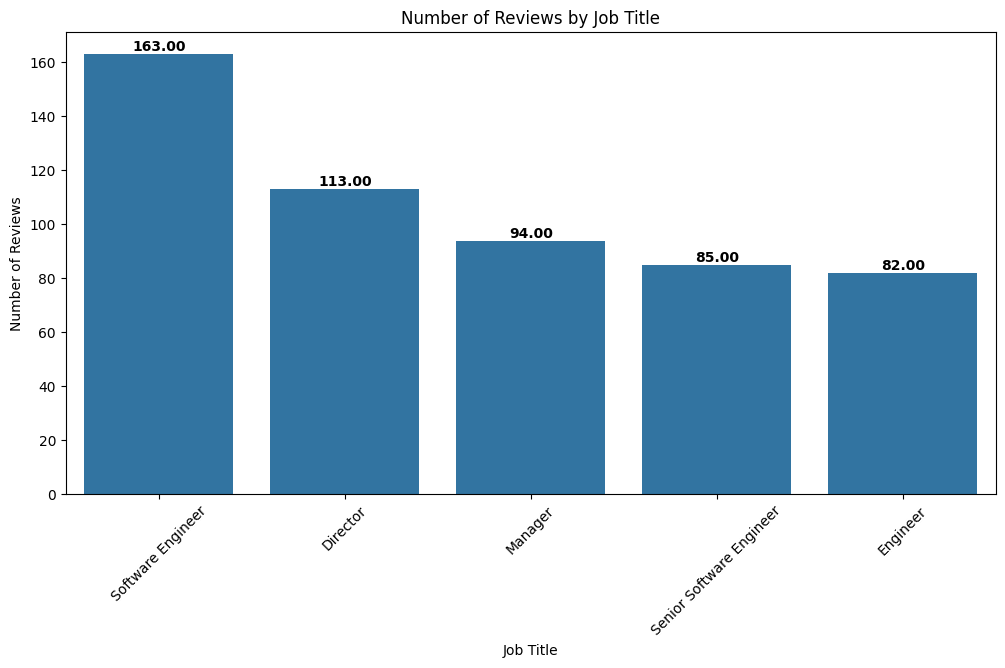

In [109]:
number_of_roles = reviews.value_counts('job title')
plt.figure(figsize=(12,6))
ax = sns.barplot(x=number_of_roles.head().index, y=number_of_roles.head().values)
plt.xticks(rotation=45)
plt.title('Number of Reviews by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Number of Reviews')
for i, v in enumerate(number_of_roles.head(5).values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Number of Reviews by Job Title.png', dpi=300, bbox_inches='tight')
plt.show()


### So the analysis reveals that the top job titles with the most reviews are primarily in the technology and management sectors.

# Average Overall rating per Job title with more no of reviews

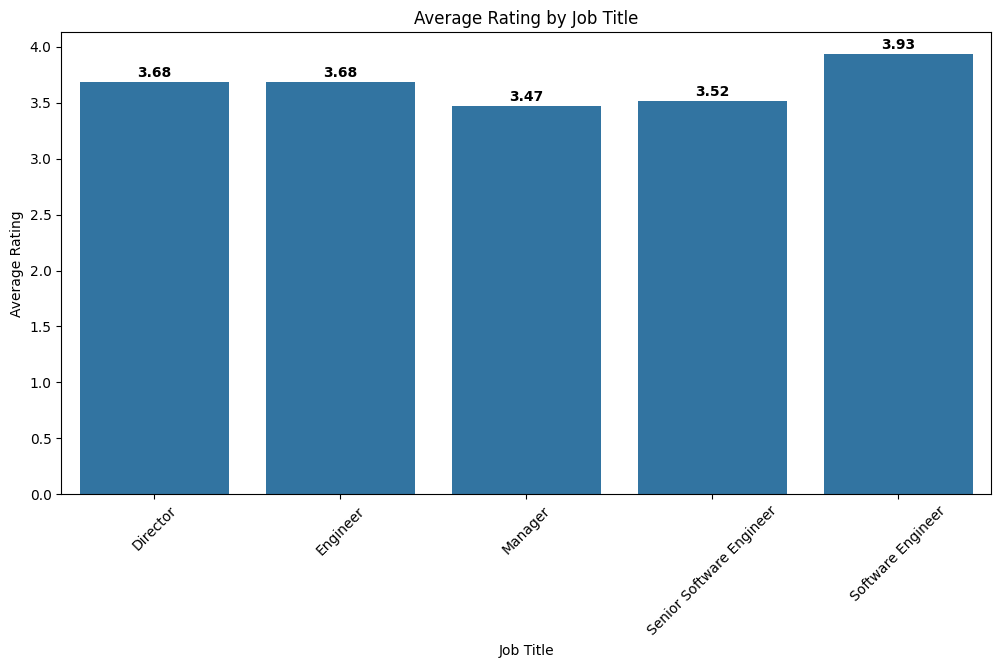

In [110]:
average_rating_jobrole = reviews.loc[reviews['job title'].isin(number_of_roles.head(5).index)].groupby('job title')['rating Overall'].mean()
plt.figure(figsize=(12,6))
ax = sns.barplot(x=average_rating_jobrole.index, y=average_rating_jobrole.values)
plt.xticks(rotation=45)
plt.title('Average Rating by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Average Rating')
for i, v in enumerate(average_rating_jobrole.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Average Rating by Job Title.png', dpi=300, bbox_inches='tight')
plt.show()

# Worklife balance vs Job role

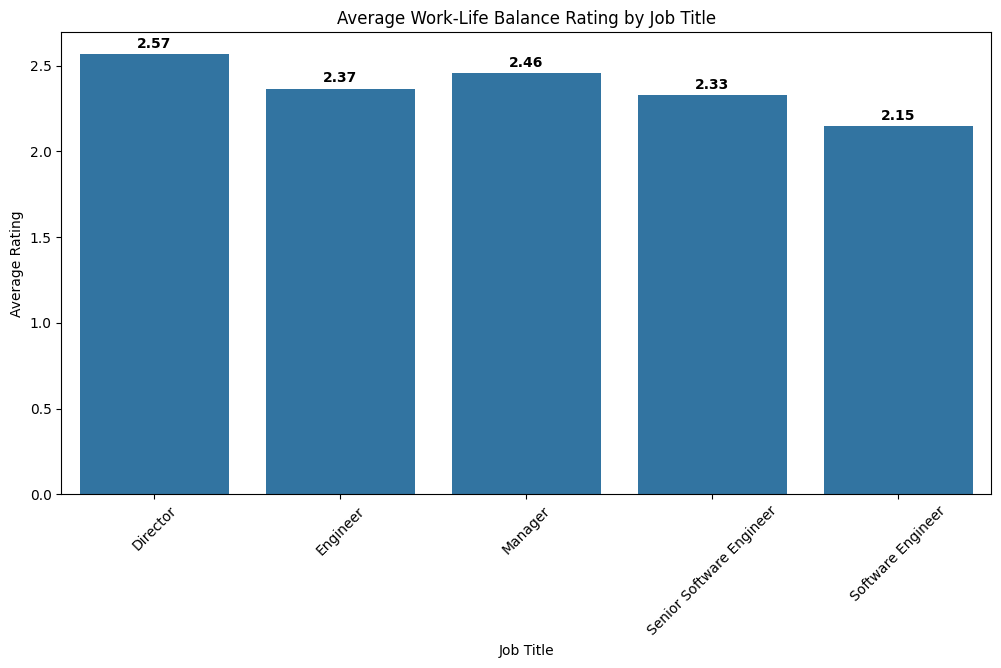

In [111]:
worklife_jobrole = reviews.loc[reviews['job title'].isin(number_of_roles.head(5).index)].groupby('job title')['rating worklifebalance'].mean()
plt.figure(figsize=(12,6))
ax = sns.barplot(x=worklife_jobrole.index, y=worklife_jobrole.values)
plt.xticks(rotation=45)
plt.title('Average Work-Life Balance Rating by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Average Rating')
for i, v in enumerate(worklife_jobrole.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Average Work-Life Balance Rating by Job Title.png', dpi=300, bbox_inches='tight')
plt.show()

# Senior Leadership vs Job role

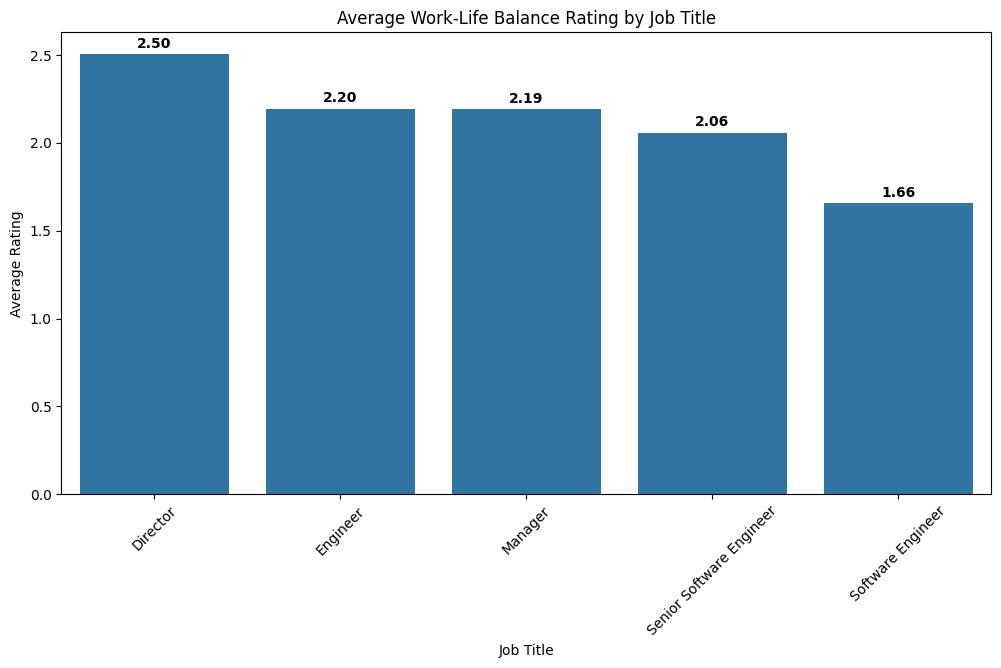

In [112]:
senior_leadership_jobtitle = reviews.loc[reviews['job title'].isin(number_of_roles.head(5).index)].groupby('job title')['ratingSeniorleadership'].mean()
plt.figure(figsize=(12,6))
ax = sns.barplot(x=senior_leadership_jobtitle.index, y=senior_leadership_jobtitle.values)
plt.xticks(rotation=45)
plt.title('Average Work-Life Balance Rating by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Average Rating')
for i, v in enumerate(senior_leadership_jobtitle.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Average Senior Leadership Rating by Job Title.png', dpi=300, bbox_inches='tight')
plt.show()

# Carrer Opportunities vs Job role

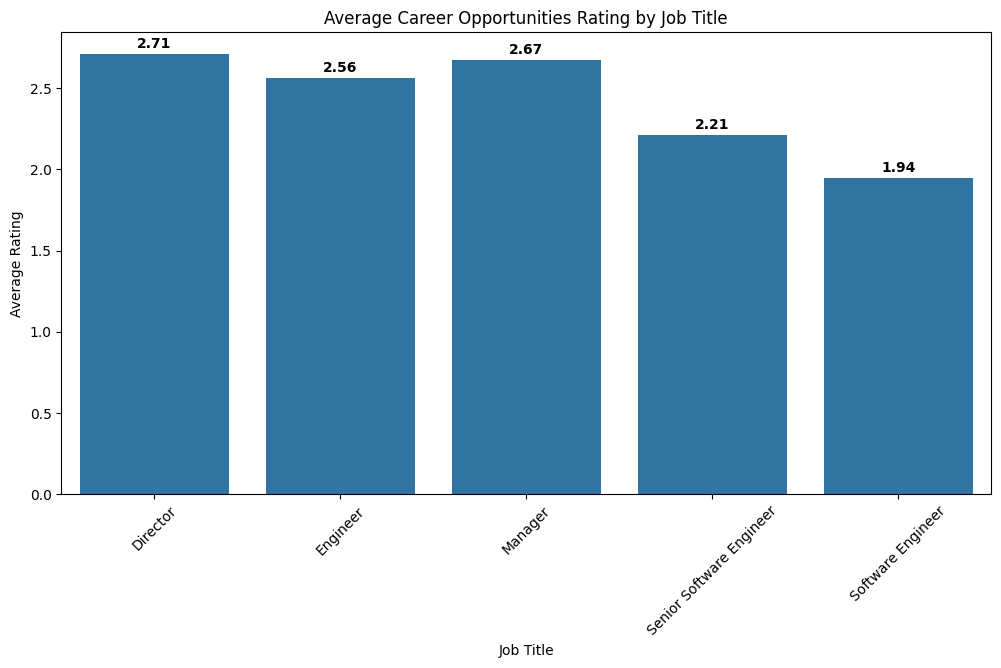

In [113]:
CareerOpportunities_jobtitle = reviews.loc[reviews['job title'].isin(number_of_roles.head(5).index)].groupby('job title')['ratingCarrerOpportunities'].mean()
plt.figure(figsize=(12,6))
ax = sns.barplot(x=CareerOpportunities_jobtitle.index, y=CareerOpportunities_jobtitle.values)
plt.xticks(rotation=45)
plt.title('Average Career Opportunities Rating by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Average Rating')
for i, v in enumerate(CareerOpportunities_jobtitle.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Average Career Opportunities Rating by Job Title.png', dpi=300, bbox_inches='tight')
plt.show()

### Software Engineers have the highest number of reviews but consistently report the lowest ratings across work-life balance, career opportunities, and senior leadership—indicating potential burnout or unmet expectations.

### Directors and Managers receive the highest ratings for work-life balance and career opportunities, reflecting greater autonomy and career visibility at senior levels.

### Despite lower category-wise scores, Software Engineers show the highest overall average rating (3.95), suggesting satisfaction in other areas like compensation or company reputation.

# 4 Location based analysis

## Top states and cities by review count

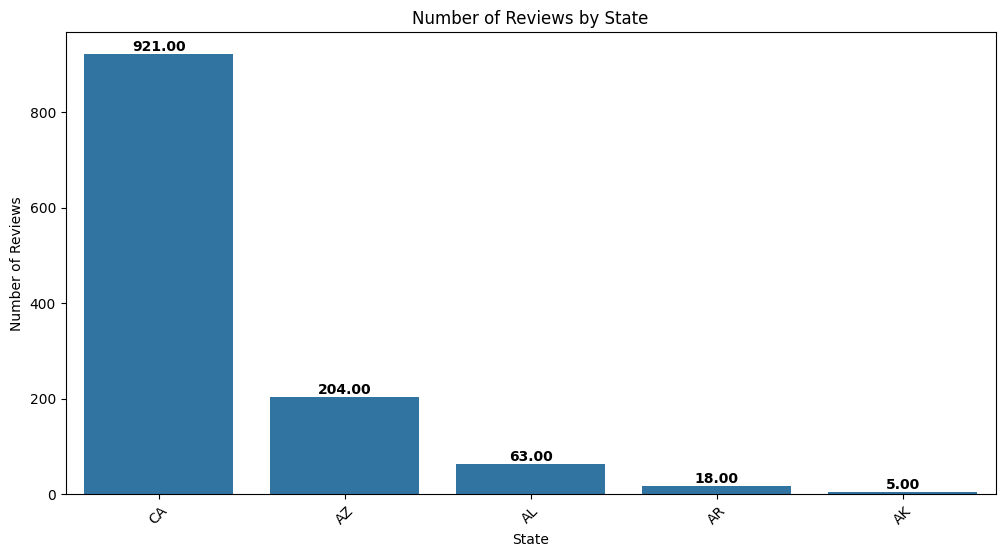

In [142]:
employeer_state = reviews.groupby('state')['Employeer ID'].agg('count').head().sort_values(ascending=False)
plt.figure(figsize=(12,6))
ax = sns.barplot(x=employeer_state.index, y=employeer_state.values)
plt.xticks(rotation=45)
plt.title('Number of Reviews by State')
plt.xlabel('State')
plt.ylabel('Number of Reviews')
for i, v in enumerate(employeer_state.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Number of Reviews by State.png', dpi=300, bbox_inches='tight')
plt.show()

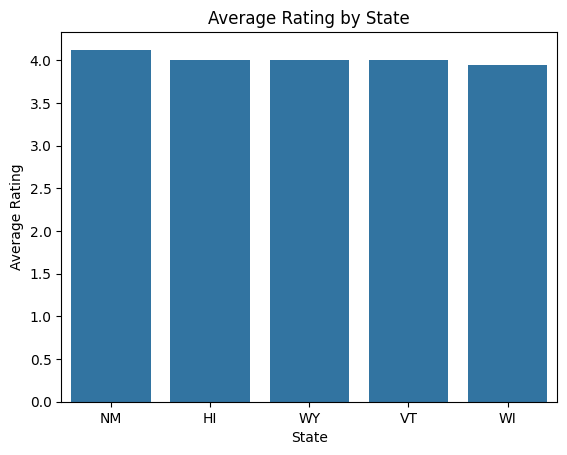

In [144]:
## States with highest number of reviews
avg_reviews_state = reviews.groupby('state')['rating Overall'].mean().sort_values(ascending=False).head()
sns.barplot(x=avg_reviews_state.index, y=avg_reviews_state.values)
plt.title('Average Rating by State')
plt.xlabel('State')
plt.ylabel('Average Rating')
for i, v in enumerate(avg_reviews_state.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.savefig('Plottings/Average Rating by State.png', dpi=300, bbox_inches='tight')
plt.show()


In [115]:
reviews.columns

Index(['Employeer ID', 'Employeer Name', 'Employement Status', 'job title',
       'length of employement', 'isCurrent Job', 'ratingCarrerOpportunities',
       'ratingBusinessoutlook', 'ratingCEO', 'ratingCompensationand Benefits',
       'ratingCulutreand Values', 'ratingDiversity and Inclusion',
       'rating Overall', 'ratingSeniorleadership', 'rating worklifebalance',
       'countHelpful', 'countNothelpful', 'summary', 'Cons', 'pros',
       'reviewdate', 'reviewtime', 'city', 'state'],
      dtype='object')